# **Lifestyle Impact on Pollution Exposure**
## introduction

This project analyzes how daily lifestyle and environmental factors influence pollution exposure.  
The study aims to identify patterns and understand how everyday activities impact exposure levels.

## Objectives
- To analyze how lifestyle and environmental factors affect pollution exposure  
- To identify patterns and relationships in exposure levels  
- To understand key factors contributing to higher pollution exposure  
- To present insights using data visualization

### Import Libraries

In [3]:
# Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [4]:
df = pd.read_csv("urban_lifestyle_impact_dataset.csv")
df

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
0,54.9,NaN,Semi-Urban,1.0,Moderate,65.4,Factory,False,34.9,True,NaN,28.0,32.50,Medium
1,42.2,Public Only,Semi-Urban,5.0,High,41.8,NaN,False,89.6,False,Low,30.0,70.58,High
2,58.0,NaN,Urban,1.0,Low,65.0,Remote,False,53.6,False,Medium,26.0,41.57,Medium
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
4,40.3,NaN,Semi-Urban,1.0,High,52.9,Factory,True,27.2,False,Medium,24.0,38.08,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,71.0,NaN,Urban,NaN,High,76.0,Office,False,57.8,True,Low,1.0,35.01,Medium
9996,5.0,Public Only,Urban,1.0,High,50.1,Factory,False,65.2,True,Low,6.0,33.05,Medium
9997,30.9,NaN,Semi-Urban,2.0,Low,63.2,Fieldwork,False,38.4,False,NaN,28.0,44.22,Medium
9998,54.9,NaN,Urban,1.0,Moderate,60.3,Fieldwork,False,23.4,False,Medium,5.0,35.52,Medium


### Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_travel_time         8876 non-null   float64
 1   vehicle_ownership         6836 non-null   object 
 2   location_type             10000 non-null  object 
 3   nearby_industries         9205 non-null   float64
 4   green_space_access        9440 non-null   object 
 5   home_air_quality          10000 non-null  float64
 6   work_location_type        9347 non-null   object 
 7   smoker_in_household       10000 non-null  bool   
 8   noise_pollution_level     10000 non-null  float64
 9   use_of_air_purifiers      10000 non-null  bool   
 10  awareness_level           8985 non-null   object 
 11  years_in_location         9480 non-null   float64
 12  pollution_exposure_score  10000 non-null  float64
 13  risk_category             10000 non-null  object 
dtypes: bool

### Handling Missing Values

In [5]:
df.isnull().sum()

daily_travel_time           1124
vehicle_ownership           3164
location_type                  0
nearby_industries            795
green_space_access           560
home_air_quality               0
work_location_type           653
smoker_in_household            0
noise_pollution_level          0
use_of_air_purifiers           0
awareness_level             1015
years_in_location            520
pollution_exposure_score       0
risk_category                  0
dtype: int64

In [6]:
df['daily_travel_time']=df['daily_travel_time'].fillna(df['daily_travel_time'].median())

Missing values in the'daily_travel_time'column were handled using the median value.

In [7]:
df['vehicle_ownership']=df['vehicle_ownership'].fillna(df['vehicle_ownership'].mode()[0])

Missing values in the'vehicle_ownership'column were handled using the mode value.

In [8]:
df['nearby_industries'] = df['nearby_industries'].fillna(df['nearby_industries'].median())

Missing values in the'nearby_industries'column were handled using the median value.

In [9]:
df['green_space_access'] =df['green_space_access'].fillna(df['green_space_access'].mode()[0])

Missing values in the 'green_space_access'column were handled using the mode value.

In [10]:
df['work_location_type']=df['work_location_type'].fillna(df['work_location_type'].mode()[0])

Missing values in the'work_location_type'column were handled using the mode value.

In [11]:
df['awareness_level']=df['awareness_level'].fillna(df['awareness_level'].mode()[0])

Missing values in the 'awareness_level'column were handled using the mode value.

In [12]:
df['years_in_location']=df['years_in_location'].fillna(df['years_in_location'].median())

Missing values in the 'years_in_location'column were handled using the median value.

### Removing Duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(10000, 14)

In [15]:
df.head()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
0,54.9,Two-wheeler,Semi-Urban,1.0,Moderate,65.4,Factory,False,34.9,True,Medium,28.0,32.50,Medium
1,42.2,Public Only,Semi-Urban,5.0,High,41.8,Fieldwork,False,89.6,False,Low,30.0,70.58,High
2,58.0,Two-wheeler,Urban,1.0,Low,65.0,Remote,False,53.6,False,Medium,26.0,41.57,Medium
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
4,40.3,Two-wheeler,Semi-Urban,1.0,High,52.9,Factory,True,27.2,False,Medium,24.0,38.08,Medium


In [16]:
df.tail()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
9995,71.0,Two-wheeler,Urban,2.0,High,76.0,Office,False,57.8,True,Low,1.0,35.01,Medium
9996,5.0,Public Only,Urban,1.0,High,50.1,Factory,False,65.2,True,Low,6.0,33.05,Medium
9997,30.9,Two-wheeler,Semi-Urban,2.0,Low,63.2,Fieldwork,False,38.4,False,Medium,28.0,44.22,Medium
9998,54.9,Two-wheeler,Urban,1.0,Moderate,60.3,Fieldwork,False,23.4,False,Medium,5.0,35.52,Medium
9999,57.9,Car,Urban,2.0,Moderate,69.1,Office,False,75.7,False,Medium,9.0,47.42,Medium


In [27]:
df.to_csv("clean_pollution_data.csv", index=False)

## Exploratory Data Analysis (EDA)
### 1. Distribution of Pollution Risk Categories

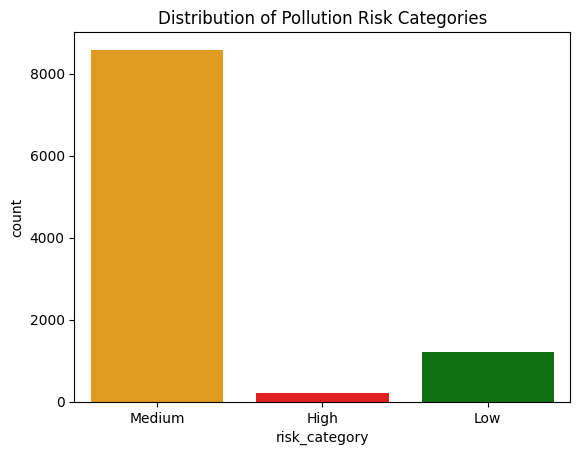

In [18]:
plt.figure()

sns.countplot(
    x='risk_category',
    hue='risk_category',
    data=df,
    palette={'Low':'green', 'Medium':'orange', 'High':'red'},
    legend=False)

plt.title("Distribution of Pollution Risk Categories")
plt.show()

### Insight

- Majority of individuals fall under the Medium risk category  
- Fewer individuals are in the High risk category  
- A noticeable portion still belongs to the Low risk category  

### 2. Impact of Daily Travel Time on Pollution Exposure

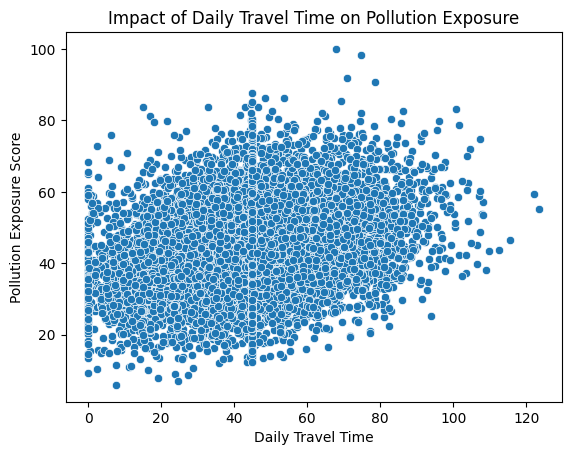

In [19]:
plt.figure()
sns.scatterplot(x='daily_travel_time', y='pollution_exposure_score', data=df)
plt.title("Impact of Daily Travel Time on Pollution Exposure")
plt.xlabel("Daily Travel Time")
plt.ylabel("Pollution Exposure Score")
plt.show()

### Insight

- Pollution exposure tends to slightly increase with higher travel time  
- The data points are widely scattered, showing no strong relationship  
- Travel time alone does not significantly determine pollution exposure  
- Other factors also play an important role in influencing exposure levels  

### 3.Effect of Vehicle Ownership on Pollution Exposure

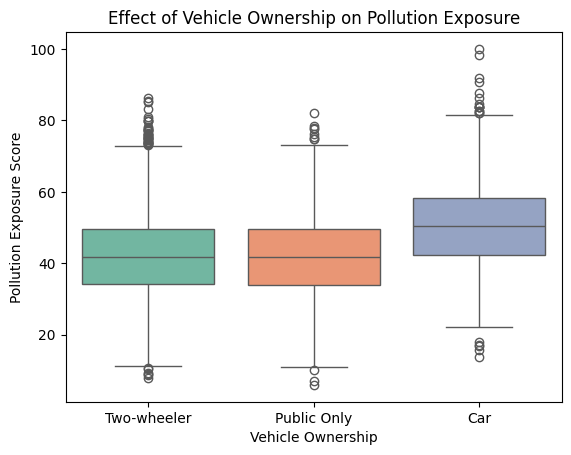

In [20]:
plt.figure()

sns.boxplot(
    x='vehicle_ownership',
    y='pollution_exposure_score',
    hue='vehicle_ownership',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Effect of Vehicle Ownership on Pollution Exposure")
plt.xlabel("Vehicle Ownership")
plt.ylabel("Pollution Exposure Score")

plt.show()

### Insight

- Individuals using cars tend to have higher pollution exposure  
- Public transport users show comparatively lower exposure levels  
- Variation in exposure is higher among private vehicle users  
- Vehicle ownership plays a significant role in pollution exposure  

### 4.Influence of Nearby Industries on Pollution Exposure

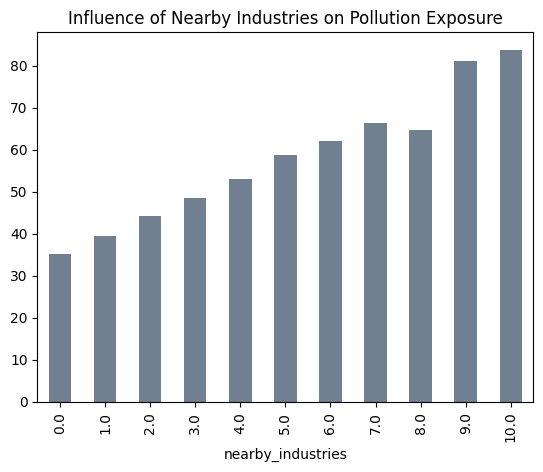

In [21]:
plt.figure()

df.groupby('nearby_industries')['pollution_exposure_score'].mean().plot(
    kind='bar',
    color='slategray'
)

plt.title("Influence of Nearby Industries on Pollution Exposure")
plt.show()

### Insight

- Pollution exposure increases as the level of nearby industries rises  
- Areas with low industrial presence show lower exposure levels  
- High industrial activity is associated with significantly higher pollution exposure  
- Proximity to industries is a key factor influencing pollution levels  

### 5. Impact of Green Space Access on Pollution Exposure

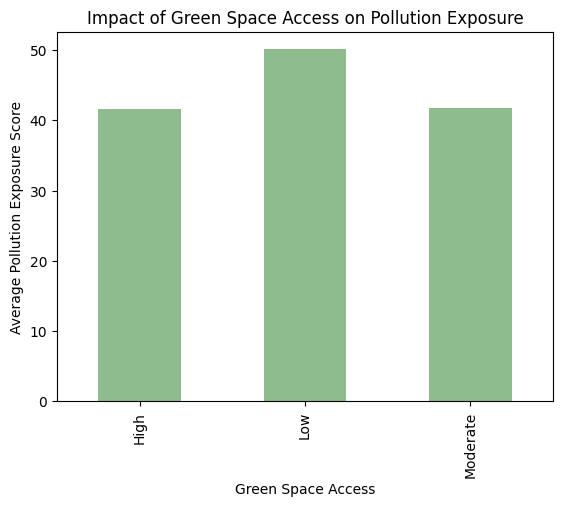

In [22]:
plt.figure()

df.groupby('green_space_access')['pollution_exposure_score'].mean().plot(
    kind='bar',
    color='darkseagreen'
)

plt.title("Impact of Green Space Access on Pollution Exposure")
plt.xlabel("Green Space Access")
plt.ylabel("Average Pollution Exposure Score")

plt.show()

### Insight

- Higher access to green space is associated with lower pollution exposure  
- Areas with low green space show increased exposure levels  
- Moderate green space provides partial reduction in exposure  
- Green spaces play an important role in reducing pollution levels  

### 6. Impact of Work Location Type on Pollution Exposure

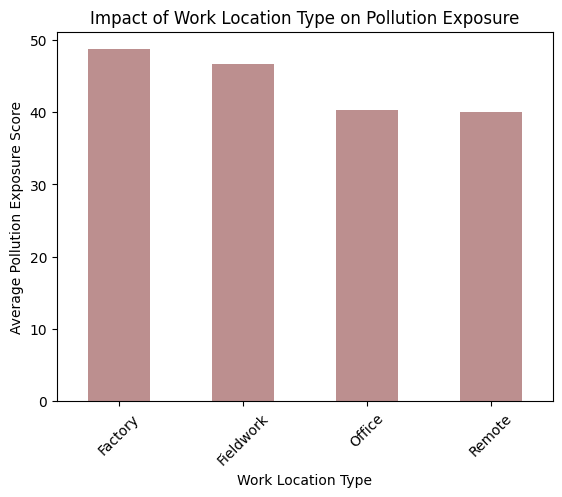

In [24]:
plt.figure()

df.groupby('work_location_type')['pollution_exposure_score'].mean().plot(
    kind='bar',
    color= 'rosybrown'
)

plt.title("Impact of Work Location Type on Pollution Exposure")
plt.xlabel("Work Location Type")
plt.xticks(rotation=45)
plt.ylabel("Average Pollution Exposure Score")

plt.show()

### Insight

- Factory and fieldwork locations show higher pollution exposure levels  
- Office-based work has moderate exposure  
- Remote work shows the lowest pollution exposure  
- Work environment plays a significant role in determining pollution exposure  

### 7.Correlation Between Variables

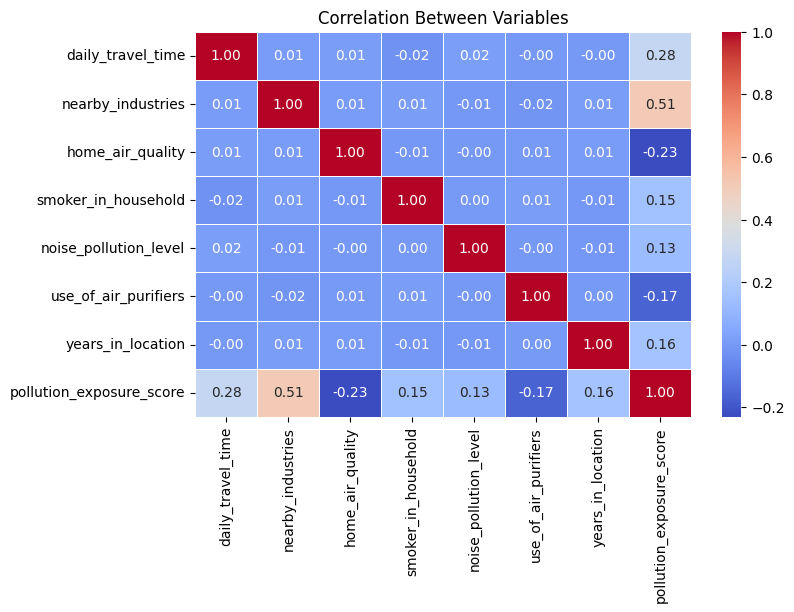

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Between Variables")
plt.show()

### Insight

- Most variables show weak to moderate correlation with pollution exposure  
- Daily travel time has a slight positive correlation with exposure  
- Strong correlations between variables are not observed  
- Pollution exposure is influenced by multiple factors rather than a single variable  

## **Overall Analysis**
This project explored the impact of lifestyle and environmental factors on pollution exposure levels.  
The analysis revealed that factors such as nearby industries, work location, indoor air quality, green space access, and travel habits influence overall exposure levels.

The visualizations and correlation analysis showed that pollution exposure is affected by a combination of multiple factors rather than a single variable.  
Higher industrial activity and poor air quality were associated with increased exposure, while green spaces and remote work environments were linked to lower exposure levels.

Overall, the study highlights the importance of sustainable lifestyle choices and environmental conditions in reducing pollution exposure and improving quality of life.